# Перенавчання на поліноміальних ознаках

У цьому notebook ви перевірите, як високий ступінь полінома може покращити train R², але погіршити test R².

## Мета

Показати на метриках, що високий ступінь полінома може призводити до перенавчання.

Очікуваний головний результат:

- найкраща модель серед малих ступенів `1-5` має test R² приблизно `0.79`;
- модель зі ступенем `18` має test R² приблизно `0.50`;
- test R² для високого ступеня нижчий більш ніж на `20%` від оптимального малого ступеня.

## Завдання

У notebook є 5 основних місць для самостійного коду:

1. Завантажити датасет.
2. Підготувати `X`, `y` і train/test split.
3. Створити pipeline для поліноміальної регресії.
4. Навчити моделі різного ступеня й порахувати метрики.
5. Перевірити падіння test R² для високого ступеня.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

RANDOM_STATE = 42
DATA_PATH = Path("data/apartment_rent_overfitting.csv")

## Завдання 1. Завантажте датасет

У клітинці нижче:

1. прочитайте CSV у змінну `df`;
2. виведіть розмір таблиці;
3. покажіть перші 5 рядків.

In [2]:
df = pd.read_csv(DATA_PATH)
display(df.shape)
display(df.head())

(90, 9)

,city,area_m2,rooms,distance_to_center_km,metro_distance_km,building_age_years,floor,renovated,monthly_rent_usd
0,Odesa,34.6,1,5.1,0.7,12,24,0,541
1,Lviv,57.0,2,3.0,0.1,48,2,0,862
2,Dnipro,33.6,1,2.7,0.5,32,16,1,466
3,Kyiv,58.3,2,12.0,2.2,33,10,0,663
4,Lviv,36.3,1,7.2,1.2,27,22,1,845


**Очікуваний результат**

- Розмір таблиці: `(90, 9)`.
- У таблиці мають бути колонки: `city`, `area_m2`, `rooms`, `distance_to_center_km`, `metro_distance_km`, `building_age_years`, `floor`, `renovated`, `monthly_rent_usd`.
- Перші рядки мають виглядати як оголошення про квартири з числовою ціною оренди.

## Швидкий огляд даних

Цю клітинку не потрібно дописувати. Вона показує діапазон цін і загальну залежність оренди від площі.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
city,90,5,Kyiv,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_m2,90.0,NaN,NaN,NaN,57.904444,17.588664,27.5,43.025,56.9,68.725,96.7
rooms,90.0,NaN,NaN,NaN,2.044444,0.806032,1.0,1.0,2.0,3.0,4.0
distance_to_center_km,90.0,NaN,NaN,NaN,5.691111,3.761444,0.7,2.475,4.7,8.3,17.1
metro_distance_km,90.0,NaN,NaN,NaN,1.04,0.558851,0.1,0.6,1.0,1.4,2.7
building_age_years,90.0,NaN,NaN,NaN,30.0,18.168376,1.0,16.75,31.5,41.75,79.0
floor,90.0,NaN,NaN,NaN,12.455556,7.342597,1.0,6.25,12.5,20.0,24.0
renovated,90.0,NaN,NaN,NaN,0.4,0.492642,0.0,0.0,0.0,1.0,1.0
monthly_rent_usd,90.0,NaN,NaN,NaN,891.911111,359.825977,223.0,579.0,879.0,1169.25,1625.0


Min rent: 223
Max rent: 1625
Mean rent: 891.9


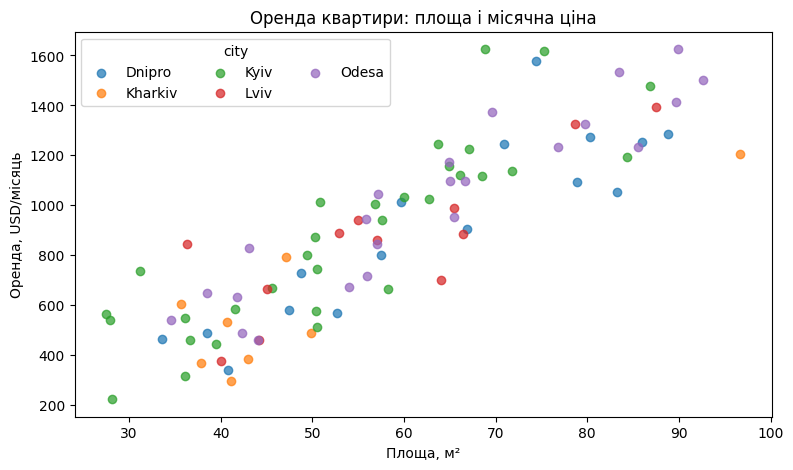

In [3]:
display(df.describe(include="all").T)

print("Min rent:", df["monthly_rent_usd"].min())
print("Max rent:", df["monthly_rent_usd"].max())
print("Mean rent:", round(df["monthly_rent_usd"].mean(), 1))

fig, ax = plt.subplots(figsize=(9, 5))
for city, part in df.groupby("city"):
    ax.scatter(part["area_m2"], part["monthly_rent_usd"], alpha=0.72, label=city)

ax.set_title("Оренда квартири: площа і місячна ціна")
ax.set_xlabel("Площа, м²")
ax.set_ylabel("Оренда, USD/місяць")
ax.legend(title="city", ncols=3)
plt.show()

- Мінімальна оренда приблизно `223` USD.
- Максимальна оренда приблизно `1625` USD.
- Середня оренда приблизно `892` USD.
- На графіку видно позитивний зв'язок між площею і ціною, але точки не лежать на одній ідеальній лінії.

## Завдання 2. Підготуйте X, y і train/test split

Для демонстрації перенавчання використовуйте тільки одну ознаку `area_m2`.

In [4]:
# TODO:
# 1. X має містити тільки колонку area_m2
# 2. y має містити monthly_rent_usd
# 3. Зробіть train_test_split з test_size=0.30 і random_state=RANDOM_STATE
# 4. Виведіть розміри train і test

X = df[['area_m2']]
y = df['monthly_rent_usd']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

display(X_train.shape)
display(X_test.shape)

(63, 1)

(27, 1)

**Очікуваний результат**

- Train size: `63` рядки.
- Test size: `27` рядків.
- `X_train` і `X_test` мають містити тільки одну колонку: `area_m2`.

## Завдання 3. Створіть функцію для поліноміальної моделі

Функція має повертати `Pipeline` з трьох кроків:

1. `PolynomialFeatures(degree=degree, include_bias=False)`;
2. `StandardScaler()`;
3. `LinearRegression()`.

In [5]:
def make_polynomial_model(degree):
     return Pipeline([
         ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
         ("scaler", StandardScaler()),
         ("model", LinearRegression()),
     ])
make_polynomial_model(3)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('poly', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


**Очікуваний результат**

Після створення функції виклик `make_polynomial_model(3)` має повертати sklearn `Pipeline`, у якому є кроки для поліноміальних ознак, масштабування та лінійної регресії.

## Завдання 4. Навчіть моделі різного ступеня

Навчіть моделі для ступенів:

```python
[1, 2, 3, 4, 5, 8, 12, 15, 18]
```

Для кожної моделі порахуйте `train_r2`, `test_r2` і `test_mae_usd`.

In [10]:
candidate_degrees = [1, 2, 3, 4, 5, 8, 12, 15, 18]
models = {}
rows = []

for degree in candidate_degrees:
    model = make_polynomial_model(degree)
    model.fit(X_train, y_train)
    
    models['model_' + str(degree)] = model
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    rows.append({
        "degree": degree,
        "train_r2": r2_score(y_train, train_pred),
        "test_r2": r2_score(y_test, test_pred),
        "test_mae_usd": mean_absolute_error(y_test, test_pred)
    })
    
metrics = pd.DataFrame(rows).round(3)
metrics
# TODO:
# Для кожного degree:
# 1. створіть модель через make_polynomial_model(degree)
# 2. навчіть її на X_train, y_train
# 3. збережіть модель у словник models
# 4. порахуйте train_pred і test_pred
# 5. додайте в rows словник з degree, train_r2, test_r2, test_mae_usd
# 6. створіть DataFrame metrics і виведіть metrics.round(3)

,degree,train_r2,test_r2,test_mae_usd
0,1,0.740,0.786,121.065
1,2,0.745,0.781,120.958
2,3,0.792,0.792,126.439
3,4,0.795,0.782,129.005
4,5,0.796,0.783,130.000
5,8,0.801,0.777,128.105
6,12,0.844,0.653,175.019
7,15,0.833,0.688,164.711
8,18,0.867,0.573,193.218


**Очікуваний результат**

Таблиця має бути близькою до такої:

| degree | train_r2 | test_r2 | test_mae_usd |
|---:|---:|---:|---:|
| 1 | 0.740 | 0.786 | 121.065 |
| 2 | 0.745 | 0.781 | 120.958 |
| 3 | 0.792 | 0.792 | 126.439 |
| 4 | 0.795 | 0.782 | 129.005 |
| 5 | 0.796 | 0.783 | 130.000 |
| 8 | 0.851 | 0.644 | 176.912 |
| 12 | 0.873 | 0.546 | 202.057 |
| 15 | 0.880 | 0.520 | 202.404 |
| 18 | 0.885 | 0.503 | 205.018 |

Невеликі відмінності в останніх знаках можливі, але загальна картина має зберегтися.

## Завдання 5. Перевірте падіння test R²

Знайдіть найкращу модель серед ступенів `1-5`, порівняйте її з моделлю ступеня `18` і порахуйте відносне падіння test R².

In [19]:
LOW_DEGREE_LIMIT = 5
HIGH_DEGREE = 18
MIN_RELATIVE_DROP = 0.20

best_low = metrics[metrics['degree'] <= LOW_DEGREE_LIMIT].sort_values("test_r2", ascending=False).iloc[0]
print("best low:", best_low)

high = metrics[metrics['degree'] == HIGH_DEGREE]
display(high)

absolute_drop = best_low['test_r2'] - high['test_r2']
print("absolute drop", absolute_drop)

relative_drop = absolute_drop / best_low["test_r2"]
print("relative drop", relative_drop.round(3))

display(relative_drop >= MIN_RELATIVE_DROP)

# TODO:
# 1. Знайдіть рядок best_low: найкращий test_r2 серед degree <= LOW_DEGREE_LIMIT
# 2. Знайдіть рядок high для degree == HIGH_DEGREE
# 3. Порахуйте absolute_drop = best_low["test_r2"] - high["test_r2"]
# 4. Порахуйте relative_drop = absolute_drop / best_low["test_r2"]
# 5. Виведіть best degree, absolute_drop і relative_drop
# 6. Перевірте assert: relative_drop >= MIN_RELATIVE_DROP

best low: degree            3.000
train_r2          0.792
test_r2           0.792
test_mae_usd    126.439
Name: 2, dtype: float64


,degree,train_r2,test_r2,test_mae_usd
8,18,0.867,0.573,193.218


absolute drop 8    0.219
Name: test_r2, dtype: float64
relative drop 8    0.277
Name: test_r2, dtype: float64


8    True
Name: test_r2, dtype: bool

**Очікуваний результат**

- Найкращий малий ступінь: `3`.
- Падіння test R²: приблизно `0.289` R² points.
- Відносне падіння: приблизно `36.5%`.
- `assert` має пройти, бо `36.5%` більше за потрібні `20%`.

## Графік train/test R²

Ця клітинка будує графік за таблицею `metrics`, яку ви створили в Завданні 4.

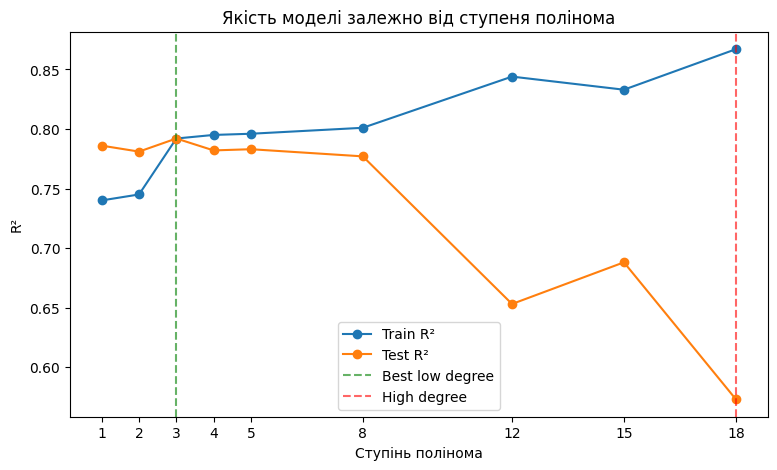

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(metrics["degree"], metrics["train_r2"], marker="o", label="Train R²")
ax.plot(metrics["degree"], metrics["test_r2"], marker="o", label="Test R²")
ax.axvline(best_low["degree"], color="green", linestyle="--", alpha=0.6, label="Best low degree")
ax.axvline(HIGH_DEGREE, color="red", linestyle="--", alpha=0.6, label="High degree")
ax.set_title("Якість моделі залежно від ступеня полінома")
ax.set_xlabel("Ступінь полінома")
ax.set_ylabel("R²")
ax.set_xticks(candidate_degrees)
ax.legend()
plt.show()

Train R² має поступово зростати приблизно до `0.885`, а test R² після малих ступенів має помітно падати. Це основний візуальний сигнал перенавчання.

## Криві прогнозу

Ця клітинка порівнює лінії прогнозу для `degree=1`, найкращого малого ступеня і `degree=18`.

KeyError: 1

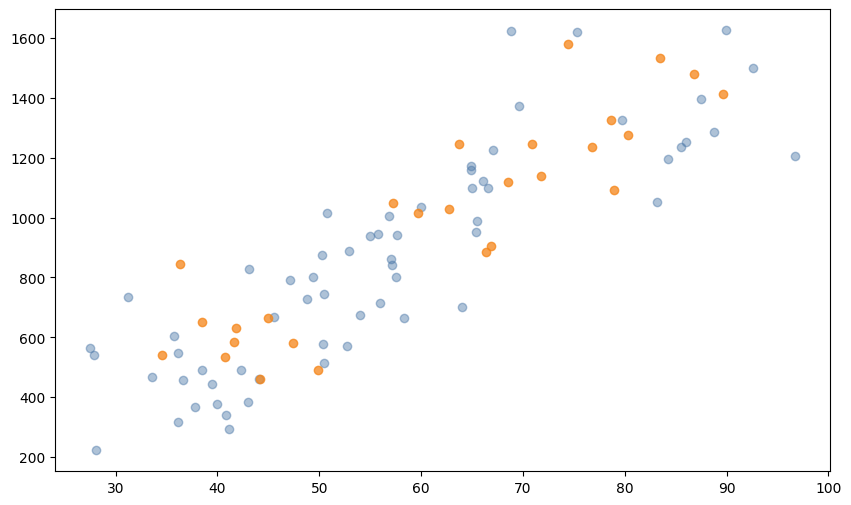

In [21]:
x_grid = pd.DataFrame({
    "area_m2": np.linspace(df["area_m2"].min(), df["area_m2"].max(), 400)
})

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_train["area_m2"], y_train, alpha=0.45, label="train", color="#4C78A8")
ax.scatter(X_test["area_m2"], y_test, alpha=0.75, label="test", color="#F58518")

for degree, color in [(1, "#54A24B"), (int(best_low["degree"]), "#2F855A"), (HIGH_DEGREE, "#E45756")]:
    y_grid = models[degree].predict(x_grid)
    ax.plot(x_grid["area_m2"], y_grid, linewidth=2.2, color=color, label=f"degree {degree}")

ax.set_title("Низький і високий ступінь полінома")
ax.set_xlabel("Площа, м²")
ax.set_ylabel("Оренда, USD/місяць")
ax.legend()
plt.show()

Лінія для `degree=18` має бути більш нестабільною, ніж лінії для малих ступенів. Вона краще підлаштовується під навчальні точки, але дає гіршу якість на тестових даних.

## Ridge для високого ступеня

Тут перевіряємо, як регуляризація змінює поведінку моделі зі ступенем `18`.

In [ ]:
ridge_high = Pipeline([
    ("poly", PolynomialFeatures(degree=HIGH_DEGREE, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0)),
])
ridge_high.fit(X_train, y_train)

ridge_train_r2 = r2_score(y_train, ridge_high.predict(X_train))
ridge_test_r2 = r2_score(y_test, ridge_high.predict(X_test))
ridge_test_mae = mean_absolute_error(y_test, ridge_high.predict(X_test))

pd.DataFrame([
    {
        "model": f"LinearRegression degree {HIGH_DEGREE}",
        "train_r2": high["train_r2"],
        "test_r2": high["test_r2"],
        "test_mae_usd": high["test_mae_usd"],
    },
    {
        "model": f"Ridge degree {HIGH_DEGREE}, alpha=10",
        "train_r2": ridge_train_r2,
        "test_r2": ridge_test_r2,
        "test_mae_usd": ridge_test_mae,
    },
]).round(3)

Для `Ridge degree 18, alpha=10` очікувано приблизно:

- train R²: `0.757`;
- test R²: `0.805`;
- test MAE: `114.8` USD.

Висновок: регуляризація може зменшити перенавчання, бо вона не дозволяє моделі робити занадто агресивні коефіцієнти.

## Висновок

Модель зі ступенем `18` має вищий train R², але значно нижчий test R², ніж оптимальна модель малого ступеня. Це означає, що модель почала підлаштовуватися під шум у навчальній вибірці. `Ridge` стабілізує модель високого ступеня і покращує test R².